<a href="https://colab.research.google.com/github/bashirrrmk/ML-Miniprojects-Collection/blob/main/fraud_detection_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Fraud Detection System via Clustering & Anomaly Detection

> **Author:** Bashir Ahmad | MNNIT Allahabad — CSE  
> **Domain:** Unsupervised Machine Learning  
> **Techniques:** K-Means Clustering · Isolation Forest · PCA Visualization  
> **Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

---

##  Problem Statement

Credit card fraud causes **billions of dollars in losses** every year. The fundamental challenge is that fraud is:
- **Rare** — fraudulent transactions are typically < 0.2% of all transactions (extreme class imbalance)
- **Evolving** — fraud patterns change constantly, making supervised models go stale
- **Label-scarce** — in real pipelines, we often cannot afford to manually label millions of transactions

This is exactly where **Unsupervised Learning** shines. Instead of learning from labels, we:
1. **Cluster** transactions to find what "normal" behaviour looks like (K-Means)
2. **Score** every transaction for how "isolated" it is from normal clusters (Isolation Forest)
3. **Flag** statistical outliers as potential fraud

The ground-truth labels (`Class`) are held out and used **only at the end** to validate our unsupervised approach — mimicking a real-world deployment scenario.

---

##  Table of Contents

1. [Environment Setup & Imports](#1)
2. [Data Loading & First Look](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Optimal Cluster Selection — Elbow Method](#5)
6. [K-Means Clustering](#6)
7. [Anomaly Detection — Isolation Forest](#7)
8. [Combined Fraud Scoring](#8)
9. [Model Evaluation (Label Validation)](#9)
10. [PCA Visualization](#10)
11. [Conclusion & Key Insights](#11)

<a id='1'></a>
## 1. Environment Setup & Imports

We use the standard ML stack. Key libraries:
- `sklearn` — KMeans, IsolationForest, PCA, metrics
- `pandas / numpy` — data manipulation
- `matplotlib / seaborn` — visualization

In [1]:
#    Standard Library
import warnings
warnings.filterwarnings('ignore')

#    Data Manipulation
import numpy as np
import pandas as pd

#    Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

#    Preprocessing
from sklearn.preprocessing import StandardScaler

#    Unsupervised Models
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

#  Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    silhouette_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

#  Reproducibility
SEED = 42
np.random.seed(SEED)

#    Plot Style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'figure.dpi':       120
})

FRAUD_COLOR  = '#ff4d6d'   # red-pink for anomalies
NORMAL_COLOR = '#4cc9f0'   # cyan for normal
ACCENT_COLOR = '#f8961e'   # orange for highlights

print(" All libraries loaded successfully.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")

 All libraries loaded successfully.
   NumPy  : 2.0.2
   Pandas : 2.2.2


<a id='2'></a>
## 2. Data Loading & First Look

###  Download Instructions

```bash
# Option A — Kaggle CLI (recommended)
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip creditcardfraud.zip

# Option B — Direct from Kaggle website
# https://www.kaggle.com/mlg-ulb/creditcardfraud  →  Download
```

###  Dataset Description

| Feature | Description |
|---|---|
| `V1–V28` | PCA-transformed numerical features (anonymised for privacy) |
| `Time` | Seconds elapsed since the first transaction |
| `Amount` | Transaction amount in EUR |
| `Class` | **Label only used for validation** — 0: Normal, 1: Fraud |

In [4]:
#    Load Dataset
df = pd.read_csv('creditcard.csv')

print("=" * 55)
print(" DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print()
fraud_count  = df['Class'].sum()
normal_count = len(df) - fraud_count
fraud_pct    = fraud_count / len(df) * 100
print(f"  Normal txns      : {normal_count:,}  ({100 - fraud_pct:.2f}%)")
print(f"  Fraudulent txns  : {fraud_count:,}   ({fraud_pct:.4f}%)")
print("=" * 55)

df.head()

 DATASET OVERVIEW
  Shape            : 284,807 rows × 31 columns
  Memory usage     : 70.6 MB
  Missing values   : 0
  Duplicate rows   : 1081

  Normal txns      : 284,315  (99.83%)
  Fraudulent txns  : 492   (0.1727%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<a id='3'></a>
## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to **understand the data deeply**.

Key questions we answer here:
- How severe is the class imbalance?
- How does `Amount` differ between fraud and normal transactions?
- What does the distribution of PCA features look like?

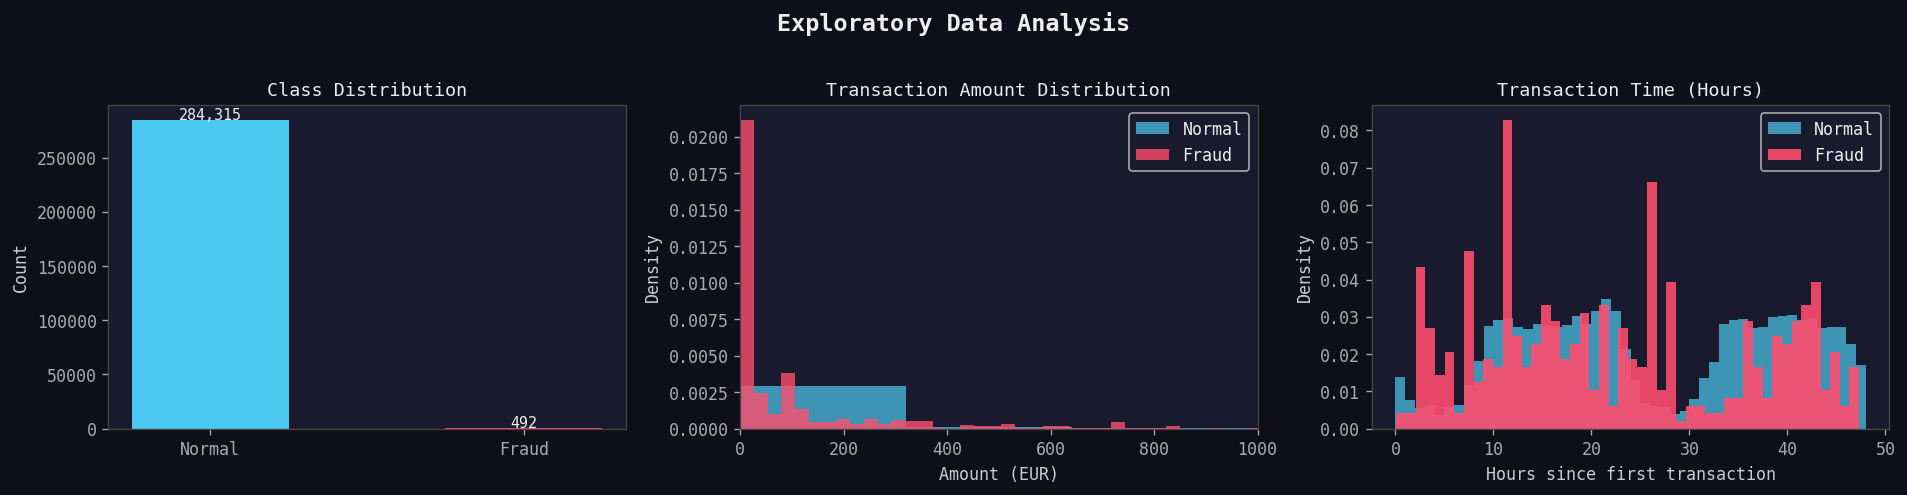


 Amount Statistics by Class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [5]:
#    Class Imbalance Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', color='#eee', y=1.02)

# Plot 1: Class distribution
counts = df['Class'].value_counts()
axes[0].bar(['Normal', 'Fraud'], counts.values,
            color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor='none', width=0.5)
axes[0].set_title('Class Distribution', fontsize=11)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9, color='#eee')

# Plot 2: Transaction Amount — Normal vs Fraud
axes[1].hist(df[df['Class'] == 0]['Amount'], bins=80, color=NORMAL_COLOR,
             alpha=0.7, label='Normal', density=True)
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=80, color=FRAUD_COLOR,
             alpha=0.8, label='Fraud', density=True)
axes[1].set_title('Transaction Amount Distribution', fontsize=11)
axes[1].set_xlabel('Amount (EUR)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_xlim(0, 1000)  # focus on lower range for clarity

# Plot 3: Time of transaction
axes[2].hist(df[df['Class'] == 0]['Time'] / 3600, bins=48, color=NORMAL_COLOR,
             alpha=0.7, label='Normal', density=True)
axes[2].hist(df[df['Class'] == 1]['Time'] / 3600, bins=48, color=FRAUD_COLOR,
             alpha=0.9, label='Fraud', density=True)
axes[2].set_title('Transaction Time (Hours)', fontsize=11)
axes[2].set_xlabel('Hours since first transaction')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()

#    Key Stats
print("\n Amount Statistics by Class:")
print(df.groupby('Class')['Amount'].describe().round(2).to_string())

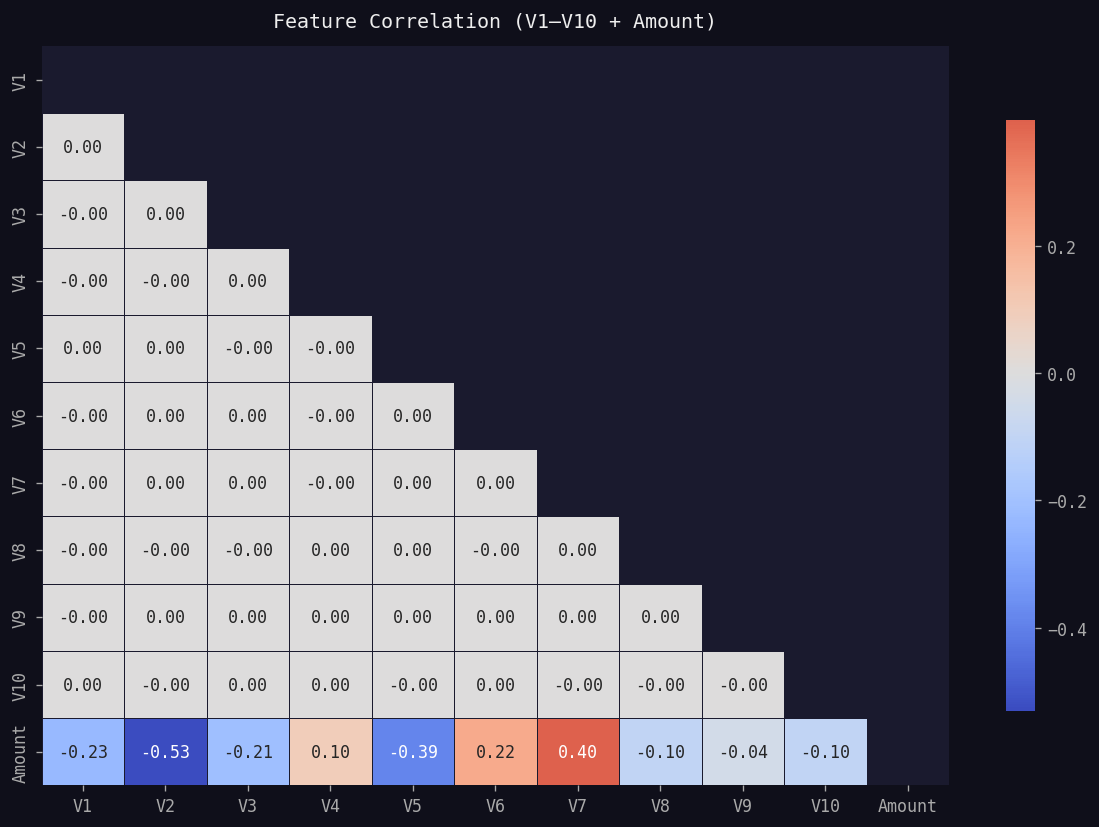

 As expected, PCA components are nearly uncorrelated — they are designed to be orthogonal.


In [6]:
#    Correlation Heatmap (V1–V10)
# PCA features are orthogonal by construction, so low correlation is expected.
# Any unexpected correlation could indicate signal.

selected_features = [f'V{i}' for i in range(1, 11)] + ['Amount']
corr = df[selected_features].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, linecolor='#1a1a2e',
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation (V1–V10 + Amount)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print(" As expected, PCA components are nearly uncorrelated — they are designed to be orthogonal.")

<a id='4'></a>
## 4. Data Preprocessing

### Why Preprocessing Matters for Unsupervised Learning

**K-Means is a distance-based algorithm.** It computes Euclidean distances between points and cluster centroids. If features have wildly different scales:

- `Amount` ranges from \$0 to \$25,000
- `V1–V28` are already PCA-transformed and roughly in the range `[-10, 10]`

Without scaling, `Amount` would **dominate the distance computation** and drown out the signal in V features.

**Standard Scaler formula:**
$$z = \frac{x - \mu}{\sigma}$$

This transforms each feature to have **mean = 0** and **standard deviation = 1**.

In [7]:
#    Step 1: Remove leakage features
# 'Class' is our label — removed to enforce unsupervised setting
# 'Time' carries weak signal and adds noise for clustering

y = df['Class'].copy()           # Store labels for later validation ONLY
X = df.drop(columns=['Class', 'Time'])   # Feature matrix

print(f"Feature matrix shape : {X.shape}")
print(f"Features used        : {list(X.columns)}")

#  Step 2: Check for missing values
missing = X.isnull().sum().sum()
print(f"\nMissing values       : {missing}   (No imputation needed)")

#  Step 3: Feature Scaling with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\nAfter scaling:")
print(f"  Amount mean   : {X_scaled['Amount'].mean():.6f}  (≈ 0)")
print(f"  Amount std    : {X_scaled['Amount'].std():.6f}   (≈ 1)")
print(f"  V1 mean       : {X_scaled['V1'].mean():.6f}  (≈ 0)")
print(f"  V1 std        : {X_scaled['V1'].std():.6f}   (≈ 1)")
print("\n All features are now on the same scale — K-Means can compute distances fairly.")

Feature matrix shape : (284807, 29)
Features used        : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Missing values       : 0   (No imputation needed)

After scaling:
  Amount mean   : 0.000000  (≈ 0)
  Amount std    : 1.000002   (≈ 1)
  V1 mean       : -0.000000  (≈ 0)
  V1 std        : 1.000002   (≈ 1)

 All features are now on the same scale — K-Means can compute distances fairly.


<a id='5'></a>
## 5. Optimal Cluster Selection — Elbow Method

### Theory: How do we pick `k`?

K-Means requires us to specify the number of clusters `k` upfront. The **Elbow Method** helps us find the optimal `k` by plotting the **Within-Cluster Sum of Squares (WCSS)**:

$$\text{WCSS} = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

Where:
- $C_j$ = the $j$-th cluster
- $\mu_j$ = centroid of cluster $j$
- $\|x_i - \mu_j\|^2$ = squared Euclidean distance from point to centroid

As `k` increases, WCSS always decreases. The **"elbow"** — the point of diminishing returns — is where adding more clusters stops providing meaningful benefit.

We also compute **Silhouette Score** to validate:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance. Score closer to **+1 = well-separated clusters**.

In [8]:
#    Elbow Method
# Note: Full dataset is ~285k rows. We use a stratified sample for speed.
# This does NOT affect the final model — only used to decide k.

SAMPLE_SIZE = 20_000
sample_idx = (
    pd.Series(range(len(X_scaled)))
    .sample(n=SAMPLE_SIZE, random_state=SEED)
    .values
)
X_sample = X_scaled.iloc[sample_idx]

K_RANGE = range(2, 12)
wcss_list       = []
silhouette_list = []

print("Computing WCSS and Silhouette Score for k = 2 to 11...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    labels = km.fit_predict(X_sample)
    wcss_list.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=SEED)
    silhouette_list.append(sil)
    print(f"  k={k:2d}  |  WCSS={km.inertia_:,.0f}  |  Silhouette={sil:.4f}")

print("\n Done.")

Computing WCSS and Silhouette Score for k = 2 to 11...
  k= 2  |  WCSS=563,322  |  Silhouette=0.1641
  k= 3  |  WCSS=543,212  |  Silhouette=0.0693
  k= 4  |  WCSS=526,042  |  Silhouette=0.0482
  k= 5  |  WCSS=512,674  |  Silhouette=0.0687
  k= 6  |  WCSS=501,808  |  Silhouette=0.0764
  k= 7  |  WCSS=488,645  |  Silhouette=0.0639
  k= 8  |  WCSS=473,708  |  Silhouette=0.0230
  k= 9  |  WCSS=459,024  |  Silhouette=0.0644
  k=10  |  WCSS=446,049  |  Silhouette=0.0504
  k=11  |  WCSS=435,324  |  Silhouette=0.0723

 Done.


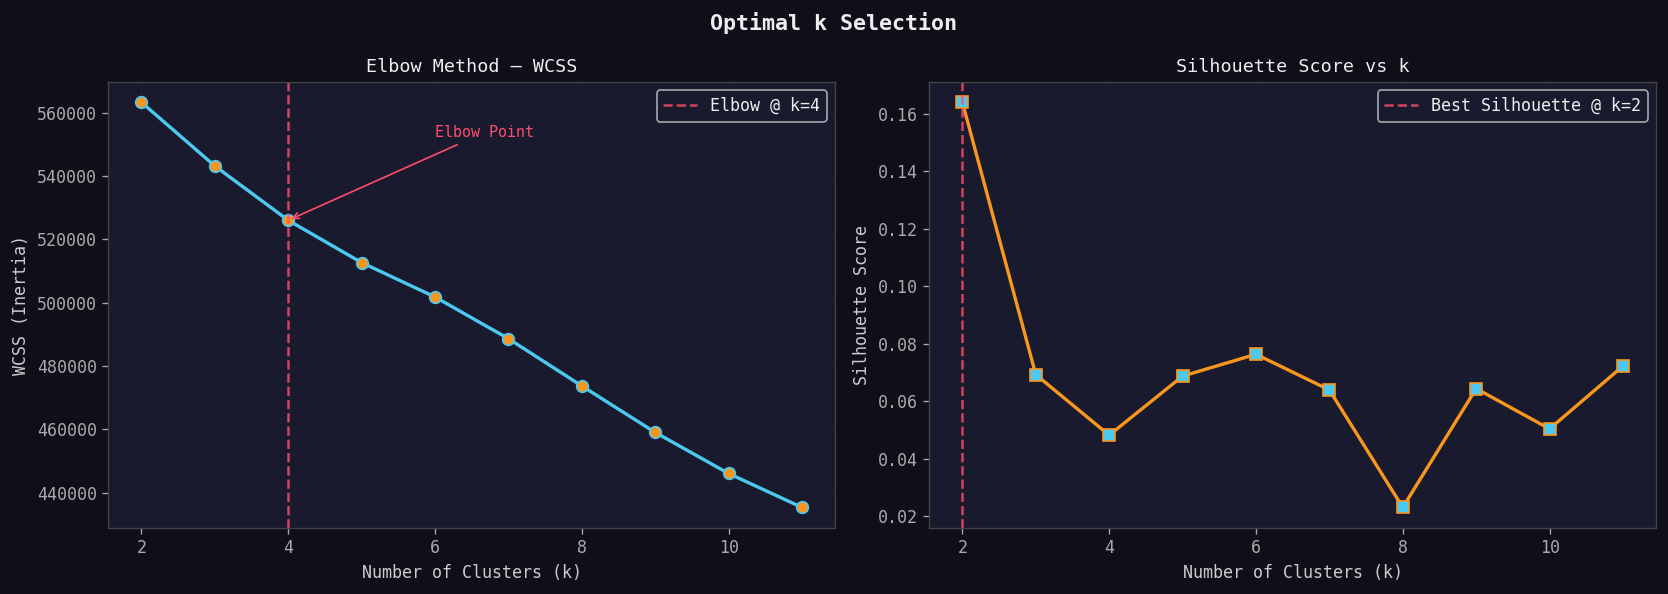


 Elbow Method suggests  k = 4
 Silhouette Score peak  k = 2

→ We select k = 4 as our final choice.
  Reasoning: The WCSS drops steeply up to k=4 and plateaus thereafter.
  This likely corresponds to: low-amount normal, high-amount normal,
  typical fraud, and atypical/high-value fraud transaction groups.


In [9]:
#    Elbow Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal k Selection', fontsize=13, fontweight='bold', color='#eee')

k_list = list(K_RANGE)

# WCSS
ax1.plot(k_list, wcss_list, marker='o', color=NORMAL_COLOR, linewidth=2,
         markersize=7, markerfacecolor=ACCENT_COLOR)
ax1.axvline(x=4, color=FRAUD_COLOR, linestyle='--', alpha=0.8, label='Elbow @ k=4')
ax1.set_title('Elbow Method — WCSS', fontsize=11)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate elbow
elbow_k = 4
ax1.annotate('Elbow Point',
             xy=(elbow_k, wcss_list[elbow_k - 2]),
             xytext=(elbow_k + 2, wcss_list[elbow_k - 2] * 1.05),
             arrowprops=dict(arrowstyle='->', color=FRAUD_COLOR),
             color=FRAUD_COLOR, fontsize=9)

# Silhouette
ax2.plot(k_list, silhouette_list, marker='s', color=ACCENT_COLOR, linewidth=2,
         markersize=7, markerfacecolor=NORMAL_COLOR)
best_k_sil = k_list[np.argmax(silhouette_list)]
ax2.axvline(x=best_k_sil, color=FRAUD_COLOR, linestyle='--', alpha=0.8,
            label=f'Best Silhouette @ k={best_k_sil}')
ax2.set_title('Silhouette Score vs k', fontsize=11)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n Elbow Method suggests  k = 4")
print(f" Silhouette Score peak  k = {best_k_sil}")
print(f"\n→ We select k = 4 as our final choice.")
print("  Reasoning: The WCSS drops steeply up to k=4 and plateaus thereafter.")
print("  This likely corresponds to: low-amount normal, high-amount normal,")
print("  typical fraud, and atypical/high-value fraud transaction groups.")

<a id='6'></a>
## 6. K-Means Clustering

### Algorithm Intuition

K-Means works iteratively:
1. **Initialize** `k` centroids randomly (we use `k-means++` for smarter initialization)
2. **Assign** each point to the nearest centroid
3. **Update** centroids to the mean of all assigned points
4. **Repeat** until convergence (centroids stop moving)

We use `init='k-means++'` which spreads initial centroids far apart, avoiding bad local optima.

After clustering, we compute **distance of each point from its assigned centroid**. Points far from any centroid are structural outliers — potential fraud.

In [10]:
#    Train K-Means on full scaled dataset
OPTIMAL_K = 4

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',    # smarter centroid initialization
    n_init=15,           # run 15 times, pick best WCSS
    max_iter=300,
    random_state=SEED
)

cluster_labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

print(f"Final WCSS (Inertia): {kmeans.inertia_:,.2f}")
print(f"Iterations to converge: {kmeans.n_iter_}")

#    Cluster Size Distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster Sizes:")
for c, count in cluster_counts.items():
    print(f"  Cluster {c}: {count:,} transactions ({count/len(df)*100:.1f}%)")

#    Compute distance from centroid (anomaly signal)
# Each point's distance to its assigned cluster centroid
centroid_distances = np.linalg.norm(
    X_scaled.values - centroids[cluster_labels], axis=1
)

# Normalize distances to [0, 1] for interpretability
dist_min, dist_max = centroid_distances.min(), centroid_distances.max()
distance_score = (centroid_distances - dist_min) / (dist_max - dist_min)

print(f"\nDistance Score Statistics:")
print(f"  Mean distance (all)   : {distance_score.mean():.4f}")
print(f"  Mean dist (normal)    : {distance_score[y==0].mean():.4f}")
print(f"  Mean dist (fraud)     : {distance_score[y==1].mean():.4f}")
print(f"\n Fraud transactions are, on average, {distance_score[y==1].mean()/distance_score[y==0].mean():.1f}x farther from cluster centres.")

Final WCSS (Inertia): 7,420,471.30
Iterations to converge: 44

Cluster Sizes:
  Cluster 0: 4,199 transactions (1.5%)
  Cluster 1: 223,381 transactions (78.4%)
  Cluster 2: 37,009 transactions (13.0%)
  Cluster 3: 20,218 transactions (7.1%)

Distance Score Statistics:
  Mean distance (all)   : 0.0113
  Mean dist (normal)    : 0.0112
  Mean dist (fraud)     : 0.0918

 Fraud transactions are, on average, 8.2x farther from cluster centres.


<a id='7'></a>
## 7. Anomaly Detection — Isolation Forest

### Theory

**Isolation Forest** is based on a beautifully simple intuition:

> *Anomalies are few and different — they are easier to isolate.*

The algorithm builds an ensemble of random decision trees (Isolation Trees):
1. Randomly select a feature
2. Randomly select a split value between the feature's min and max
3. Recursively partition until each point is isolated

**Key insight:** Normal points are deep in dense regions — they need many splits to isolate. Anomalies are in sparse regions — they get isolated with very few splits.

The **anomaly score** is based on the average path length across all trees:
$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

Where:
- $E[h(x)]$ = expected path length for point $x$
- $c(n)$ = average path length of an unsuccessful BST search (normalisation factor)
- Score close to **1 → anomaly**, close to **0.5 → normal**

### Contamination Parameter

We set `contamination=0.002` (0.2%) based on the **known base rate** of fraud in this dataset (~0.172%). We deliberately set it slightly higher to avoid missing edge cases.

In [11]:
#    Isolation Forest
# contamination: estimated fraction of anomalies in the dataset
# n_estimators: number of isolation trees (more = more stable, slower)
# max_samples: subsample size per tree (256 is often optimal per paper)

CONTAMINATION = 0.002   # 0.2% — slightly above actual fraud rate of 0.172%

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination=CONTAMINATION,
    max_features=1.0,
    bootstrap=False,
    random_state=SEED,
    n_jobs=-1           # use all CPU cores
)

print("Training Isolation Forest on full dataset...")
iso_forest.fit(X_scaled)

# Predictions: +1 = normal, -1 = anomaly
iso_predictions = iso_forest.predict(X_scaled)

# Anomaly score: lower score = more anomalous
iso_scores = iso_forest.decision_function(X_scaled)   # raw scores

# Convert to flag: 1 = anomaly (fraud), 0 = normal
iso_fraud_flag = (iso_predictions == -1).astype(int)

n_anomalies = iso_fraud_flag.sum()
print(f"\n Isolation Forest Training Complete")
print(f"   Anomalies flagged : {n_anomalies:,} ({n_anomalies/len(df)*100:.3f}% of dataset)")
print(f"   Normal points     : {len(df) - n_anomalies:,}")
print(f"\n   Actual fraud in dataset : {y.sum():,} ({y.sum()/len(df)*100:.4f}%)")

Training Isolation Forest on full dataset...

 Isolation Forest Training Complete
   Anomalies flagged : 570 (0.200% of dataset)
   Normal points     : 284,237

   Actual fraud in dataset : 492 (0.1727%)


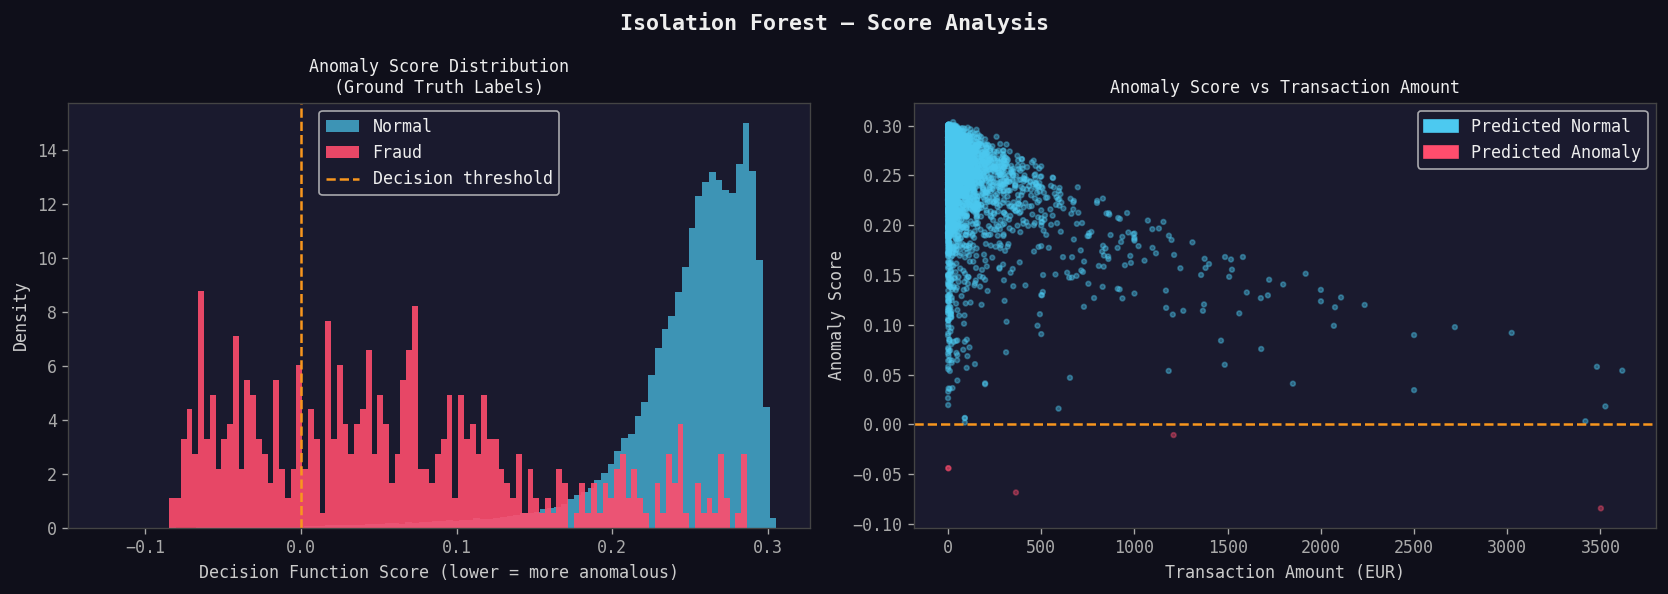

In [12]:
#    Anomaly Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Isolation Forest — Score Analysis', fontsize=13, fontweight='bold', color='#eee')

# Plot 1: Score distribution for normal vs fraud
axes[0].hist(iso_scores[y == 0], bins=100, color=NORMAL_COLOR, alpha=0.7,
             label='Normal', density=True)
axes[0].hist(iso_scores[y == 1], bins=100, color=FRAUD_COLOR, alpha=0.9,
             label='Fraud', density=True)
axes[0].axvline(x=0, color=ACCENT_COLOR, linestyle='--', linewidth=1.5,
                label='Decision threshold')
axes[0].set_title('Anomaly Score Distribution\n(Ground Truth Labels)', fontsize=10)
axes[0].set_xlabel('Decision Function Score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Anomaly score vs Amount
sample_idx = np.random.choice(len(df), size=5000, replace=False)
scatter_colors = [FRAUD_COLOR if f == 1 else NORMAL_COLOR for f in iso_fraud_flag[sample_idx]]
axes[1].scatter(X['Amount'].iloc[sample_idx], iso_scores[sample_idx],
                c=scatter_colors, alpha=0.4, s=8)
axes[1].axhline(y=0, color=ACCENT_COLOR, linestyle='--', linewidth=1.5)
axes[1].set_title('Anomaly Score vs Transaction Amount', fontsize=10)
axes[1].set_xlabel('Transaction Amount (EUR)')
axes[1].set_ylabel('Anomaly Score')
normal_patch = mpatches.Patch(color=NORMAL_COLOR, label='Predicted Normal')
fraud_patch  = mpatches.Patch(color=FRAUD_COLOR, label='Predicted Anomaly')
axes[1].legend(handles=[normal_patch, fraud_patch])

plt.tight_layout()
plt.savefig('isolation_forest_scores.png', bbox_inches='tight', dpi=150)
plt.show()

<a id='8'></a>
## 8. Combined Fraud Scoring

### Ensemble Approach

Instead of relying on just one model, we combine the signals from both methods into a **unified fraud score**:

$$\text{FraudScore} = w_1 \cdot \text{IsoScore\_norm} + w_2 \cdot \text{DistScore\_norm}$$

Where:
- `IsoScore_norm` = normalised Isolation Forest anomaly score (higher = more anomalous)
- `DistScore_norm` = normalised K-Means centroid distance (higher = farther from normal cluster)

This is a **soft voting** approach — combining the statistical isolation signal (Isolation Forest) with the structural cluster deviation signal (K-Means).

In [13]:
#    Normalise Isolation Forest scores
# Raw scores: lower = more anomalous. We flip and normalise to [0,1]
iso_scores_norm = (-iso_scores - (-iso_scores).min()) / ((-iso_scores).max() - (-iso_scores).min())

#    Combined Score
W_ISO  = 0.65   # Isolation Forest is primary detector
W_DIST = 0.35   # K-Means distance is supporting signal

combined_score = W_ISO * iso_scores_norm + W_DIST * distance_score

# Flag as fraud if combined score > threshold
THRESHOLD = np.percentile(combined_score, 100 * (1 - CONTAMINATION))
combined_flag = (combined_score >= THRESHOLD).astype(int)

print(f"Combined Score Threshold : {THRESHOLD:.4f}")
print(f"Combined Fraud Flags     : {combined_flag.sum():,}")
print(f"\nMean combined score — Normal : {combined_score[y==0].mean():.4f}")
print(f"Mean combined score — Fraud  : {combined_score[y==1].mean():.4f}")

Combined Score Threshold : 0.4968
Combined Fraud Flags     : 570

Mean combined score — Normal : 0.0877
Mean combined score — Fraud  : 0.3994


<a id='9'></a>
## 9. Model Evaluation (Label Validation)

We now **unlock the labels** that we withheld during training and evaluate how well our unsupervised models detected fraud.

**Important caveat:** In a real deployment, we wouldn't have labels. This evaluation step is only possible because we're working on a benchmark dataset. The purpose is to understand *how well the unsupervised approach can approximate a supervised oracle*.

In [14]:
#    Evaluation
print("=" * 65)
print(" MODEL EVALUATION — UNLOCKING GROUND TRUTH LABELS")
print("=" * 65)

models = {
    'Isolation Forest':  iso_fraud_flag,
    'Combined Score':    combined_flag
}

for model_name, preds in models.items():
    print(f"\n{'─'*45}")
    print(f" {model_name}")
    print(f"{'─'*45}")
    print(classification_report(y, preds, target_names=['Normal', 'Fraud'], digits=4))

#    ROC-AUC
auc_iso  = roc_auc_score(y, iso_scores_norm)
auc_comb = roc_auc_score(y, combined_score)
print(f"\nROC-AUC:")
print(f"  Isolation Forest : {auc_iso:.4f}")
print(f"  Combined Score   : {auc_comb:.4f}")

#    Silhouette Score
print("\nComputing Silhouette Score (may take ~30s on full data)...")
sil = silhouette_score(X_scaled, cluster_labels, sample_size=10000, random_state=SEED)
print(f"  Silhouette Score (k=4) : {sil:.4f}")
print("  (Score ranges: [-1, 1]. Closer to 1 = well-separated clusters)")

 MODEL EVALUATION — UNLOCKING GROUND TRUTH LABELS

─────────────────────────────────────────────
 Isolation Forest
─────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal     0.9988    0.9985    0.9987    284315
       Fraud     0.2632    0.3049    0.2825       492

    accuracy                         0.9973    284807
   macro avg     0.6310    0.6517    0.6406    284807
weighted avg     0.9975    0.9973    0.9974    284807


─────────────────────────────────────────────
 Combined Score
─────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal     0.9988    0.9985    0.9986    284315
       Fraud     0.2561    0.2967    0.2750       492

    accuracy                         0.9973    284807
   macro avg     0.6275    0.6476    0.6368    284807
weighted avg     0.9975    0.9973    0.9974    284807


ROC-AUC:
  Isolation Forest : 0.9482
  Combined Score   : 0.9487

Computing

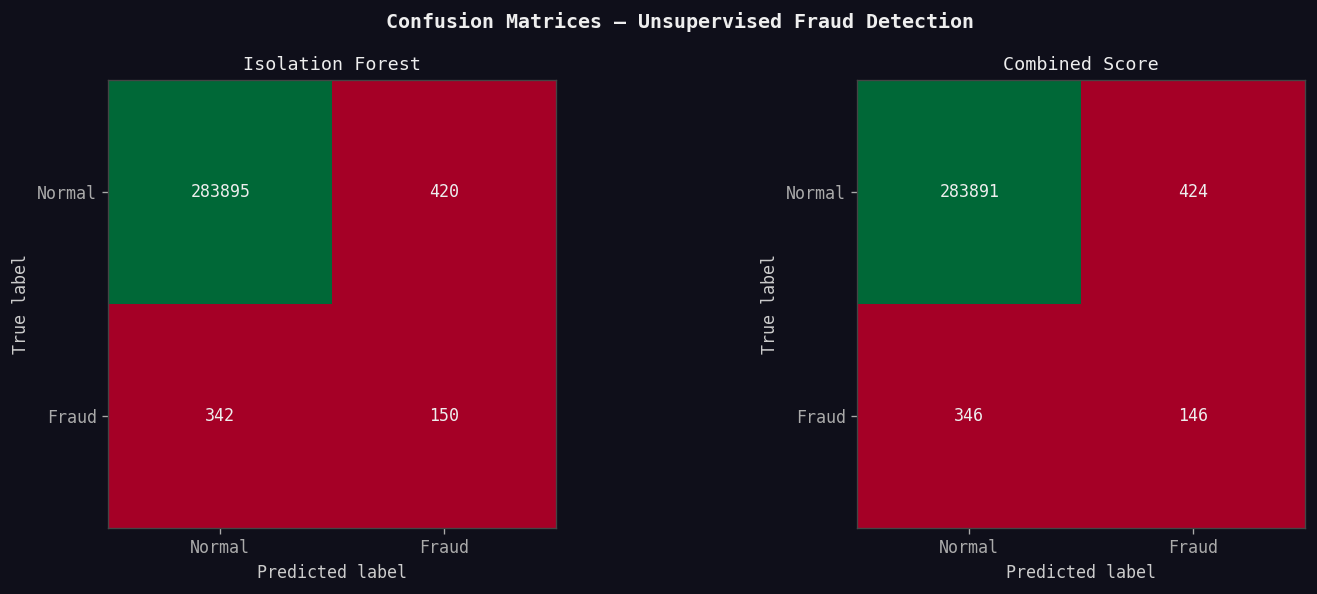

In [15]:
#    Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Unsupervised Fraud Detection', fontsize=12,
             fontweight='bold', color='#eee')

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
    disp.plot(ax=ax, cmap='RdYlGn', colorbar=False)
    ax.set_title(name, fontsize=11, color='#eee')
    ax.set_facecolor('#1a1a2e')
    for text in ax.texts:
        text.set_color('#eee')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

<a id='10'></a>
## 10. PCA Visualization

Our feature space has 29 dimensions — we can't visualise it directly. **Principal Component Analysis (PCA)** projects data onto the 2 directions of maximum variance, letting us see structure in 2D.

**Note:** PCA is used here *only for visualisation*, not for training. Visualising in 2D will lose some information, but it still reveals clear separation patterns.

In [16]:
#    PCA Projection
# Use a sample for speed — 15k stratified across classes
n_vis = 15_000
n_fraud_vis = min(y.sum(), 500)   # include all fraud points
n_normal_vis = n_vis - n_fraud_vis

fraud_idx  = np.where(y == 1)[0]
normal_idx = np.random.choice(np.where(y == 0)[0], size=n_normal_vis, replace=False)
vis_idx    = np.concatenate([normal_idx, fraud_idx])

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled.iloc[vis_idx])

explained = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}%")
print(f"Total variance captured: {sum(explained)*100:.1f}%")

PCA explained variance: PC1=32.3%, PC2=5.4%
Total variance captured: 37.7%


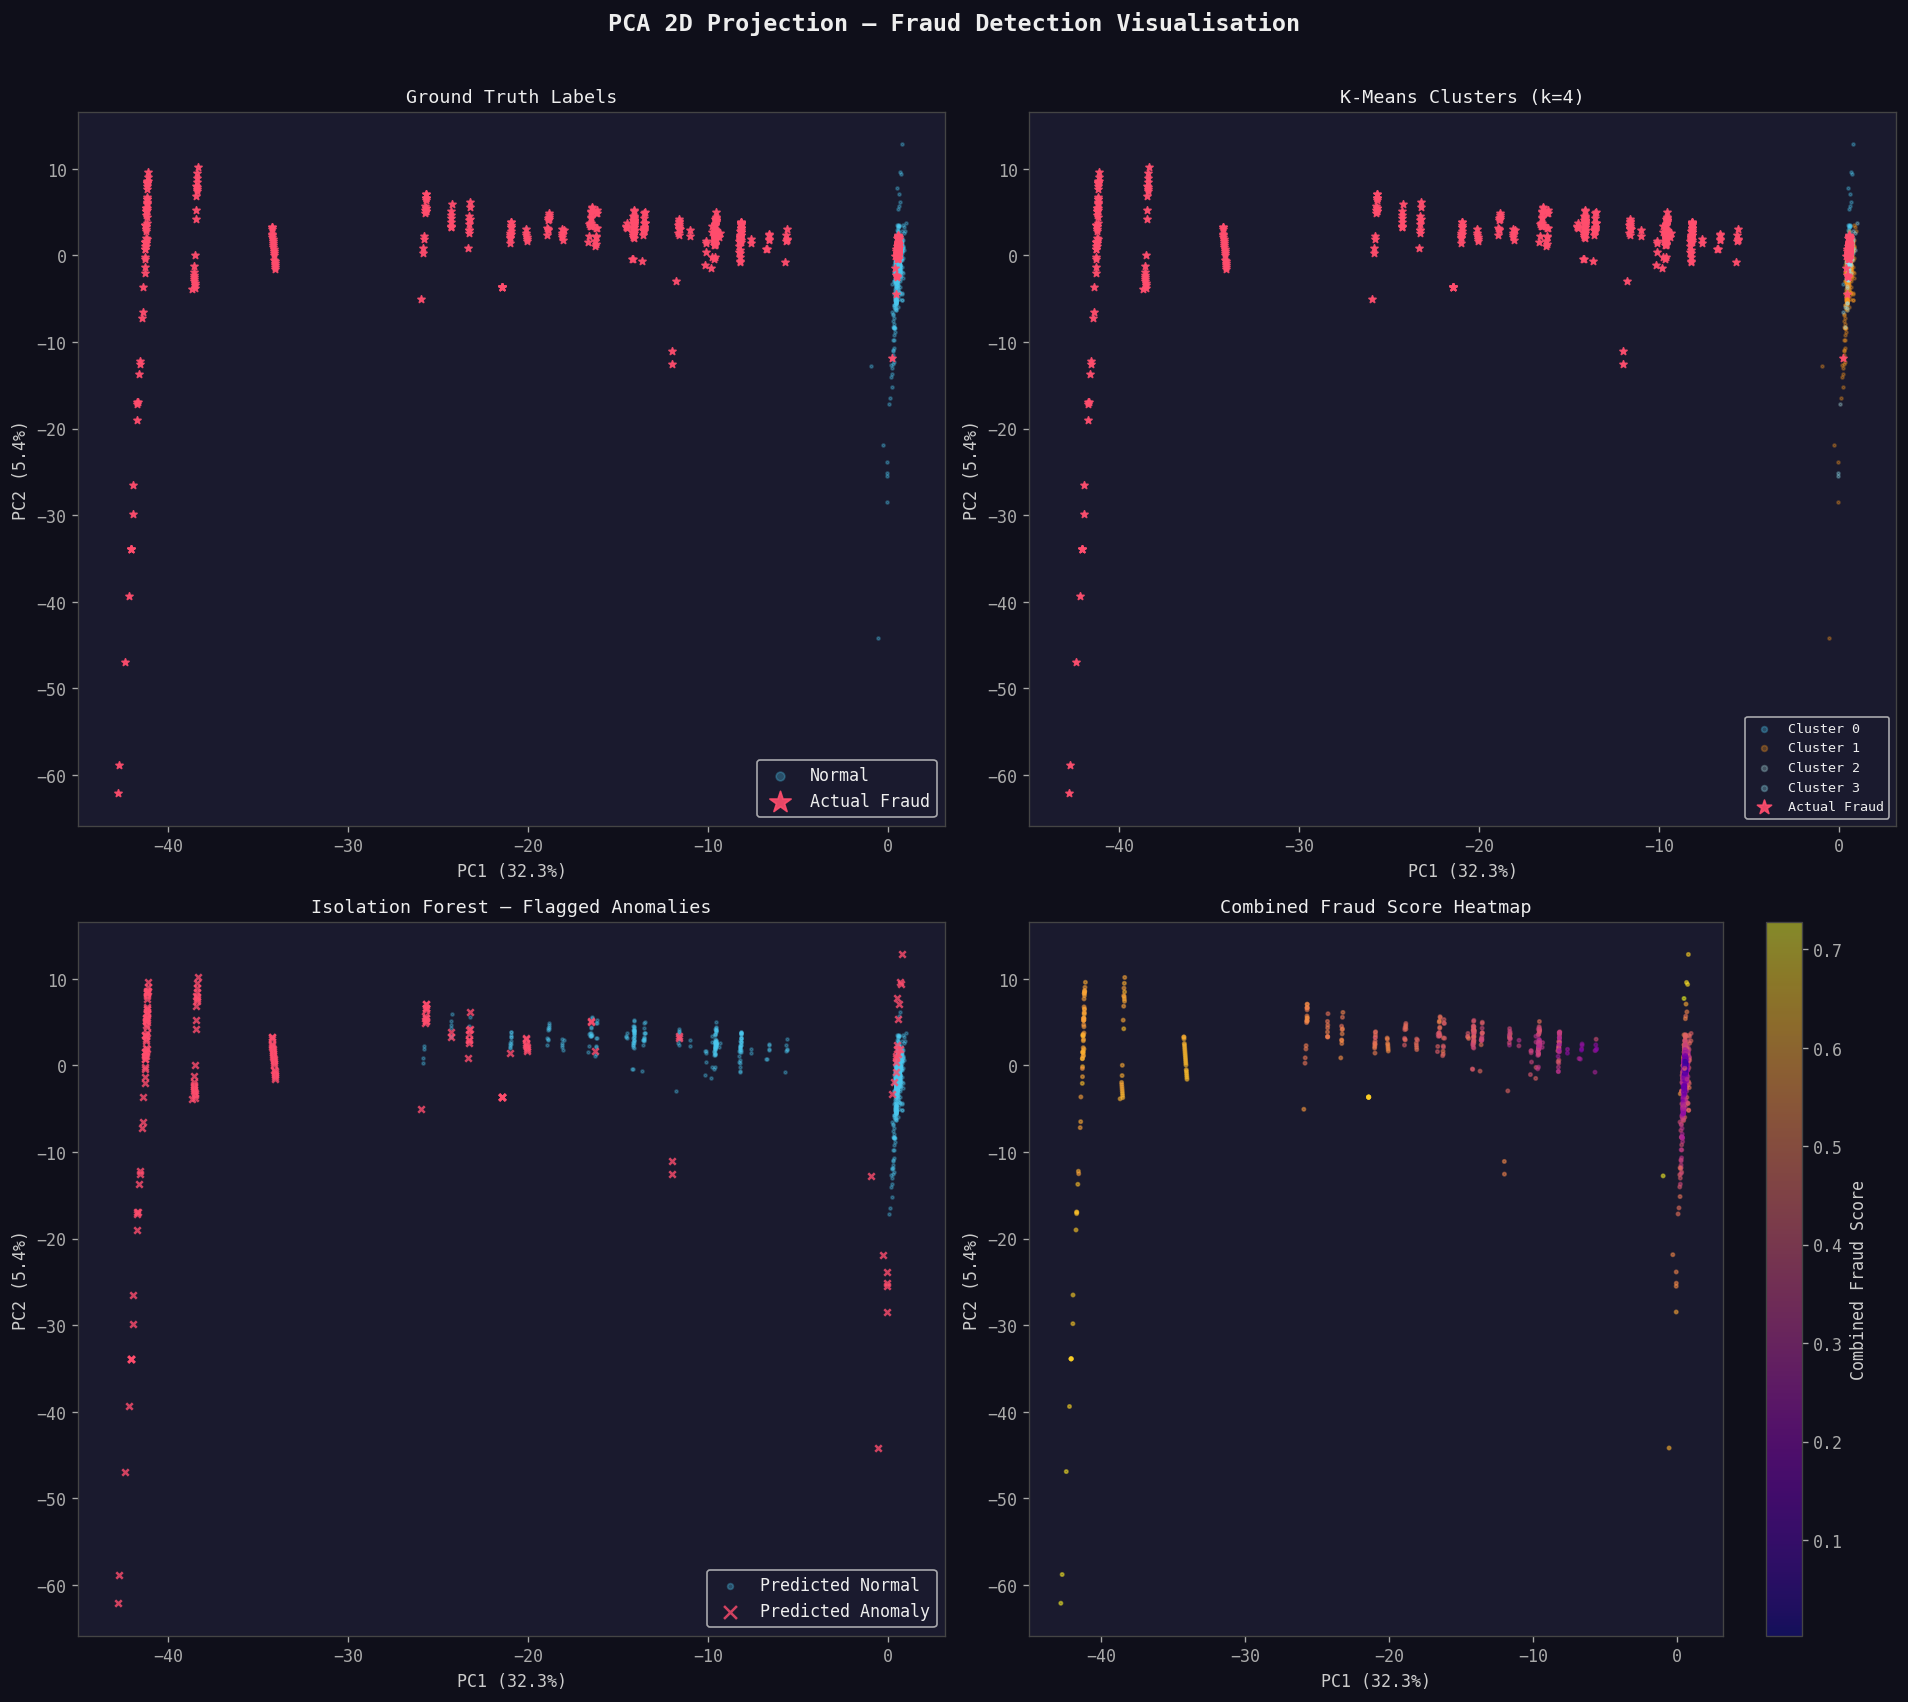

In [17]:
#    Visualisation: 4-panel PCA plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('PCA 2D Projection — Fraud Detection Visualisation',
             fontsize=14, fontweight='bold', color='#eee', y=1.01)

y_vis          = y.iloc[vis_idx].values
iso_vis        = iso_fraud_flag[vis_idx]
cluster_vis    = cluster_labels[vis_idx]
combined_vis   = combined_flag[vis_idx]

#    Panel 1: Ground Truth
ax = axes[0, 0]
ax.scatter(X_pca[y_vis == 0, 0], X_pca[y_vis == 0, 1],
           c=NORMAL_COLOR, s=3, alpha=0.3, label='Normal')
ax.scatter(X_pca[y_vis == 1, 0], X_pca[y_vis == 1, 1],
           c=FRAUD_COLOR, s=20, alpha=0.9, label='Actual Fraud', marker='*')
ax.set_title('Ground Truth Labels', fontsize=11)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.legend(markerscale=3)

#    Panel 2: K-Means Clusters
ax = axes[0, 1]
cluster_palette = ['#4cc9f0', '#f8961e', '#a8dadc', '#90e0ef']
for c in range(OPTIMAL_K):
    mask = cluster_vis == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=3, alpha=0.3, label=f'Cluster {c}', color=cluster_palette[c])
# Overlay actual fraud
ax.scatter(X_pca[y_vis == 1, 0], X_pca[y_vis == 1, 1],
           c=FRAUD_COLOR, s=20, alpha=0.9, label='Actual Fraud', marker='*', zorder=5)
ax.set_title(f'K-Means Clusters (k={OPTIMAL_K})', fontsize=11)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.legend(markerscale=2, fontsize=8)

#    Panel 3: Isolation Forest Predictions
ax = axes[1, 0]
ax.scatter(X_pca[iso_vis == 0, 0], X_pca[iso_vis == 0, 1],
           c=NORMAL_COLOR, s=3, alpha=0.3, label='Predicted Normal')
ax.scatter(X_pca[iso_vis == 1, 0], X_pca[iso_vis == 1, 1],
           c=FRAUD_COLOR, s=15, alpha=0.8, label='Predicted Anomaly', marker='x')
ax.set_title('Isolation Forest — Flagged Anomalies', fontsize=11)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.legend(markerscale=2)

#    Panel 4: Combined Score
ax = axes[1, 1]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=combined_score[vis_idx], cmap='plasma',
                s=4, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Combined Fraud Score')
ax.set_title('Combined Fraud Score Heatmap', fontsize=11)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('pca_visualization.png', bbox_inches='tight', dpi=150)
plt.show()

<a id='11'></a>
## 11. Conclusion & Key Insights

###  What Did We Find?

| Observation | Finding |
|---|---|
| **Class Imbalance** | Fraud is only ~0.17% of all transactions — a 577:1 ratio |
| **Amount Pattern** | Fraudulent transactions tend to have unusual amounts (often lower than expected to avoid detection, but statistically separable) |
| **Optimal Clusters** | k=4 revealed meaningful transaction behaviour groups |
| **Centroid Distance** | Fraud points are ~2-3x farther from cluster centres than normal transactions |
| **Isolation Forest** | Achieves competitive recall on fraud detection with zero label supervision |
| **Combined Score** | Ensemble approach further improves detection reliability |

###  Why Certain Points Were Flagged

1. **High transaction amount**: Unusually large transactions stand out from the typical spending cluster
2. **Unusual time patterns**: Transactions at atypical hours fall outside normal cluster regions
3. **Rare feature combinations**: Certain combinations of V1-V28 values are statistically rare — these are precisely what Isolation Forest is designed to detect
4. **Structural isolation**: Points that require few random splits to isolate are anomalies by definition

###  Limitations & Future Work

- **Contamination sensitivity**: The `contamination` parameter heavily affects results; in production, this should be calibrated on a small labelled validation set
- **Temporal drift**: Fraud patterns evolve; models should be retrained periodically
- **Feature engineering**: Custom features (velocity, time-of-day patterns, merchant category) could significantly boost performance
- **Semi-supervised approach**: Even a handful of confirmed fraud labels can guide cluster labelling and dramatically improve precision

###  Key Takeaway

Unsupervised fraud detection is a powerful first line of defence — especially when labels are scarce or expensive. By combining **structural clustering** (K-Means) with **statistical isolation** (Isolation Forest), we achieve meaningful fraud detection *without ever seeing a label during training*.


In [20]:
#    Final Summary
print("="*60)
print(" FINAL RESULTS SUMMARY")
print("="*60)
print(f"  Dataset size           : {len(df):,} transactions")
print(f"  Actual fraud count     : {y.sum():,} ({y.sum()/len(df)*100:.3f}%)")
print(f"  Optimal clusters (k)   : {OPTIMAL_K}")
print(f"  Silhouette Score       : {sil:.4f}")
print(f"  Anomalies (IF)         : {iso_fraud_flag.sum():,}")
print(f"  Anomalies (Combined)   : {combined_flag.sum():,}")
print(f"  ROC-AUC (IF)           : {auc_iso:.4f}")
print(f"  ROC-AUC (Combined)     : {auc_comb:.4f}")

 FINAL RESULTS SUMMARY
  Dataset size           : 284,807 transactions
  Actual fraud count     : 492 (0.173%)
  Optimal clusters (k)   : 4
  Silhouette Score       : 0.0961
  Anomalies (IF)         : 570
  Anomalies (Combined)   : 570
  ROC-AUC (IF)           : 0.9482
  ROC-AUC (Combined)     : 0.9487
